# Proyecto: Impacto de la Inteligencia Artificial en el Empleo (Hacia 2030)

**Asignatura:** MCDI500 — Programación para Ciencia de Datos  
**Fase:** 3 — Semana 2  
**Autores:** Arturo Knopke · Nicolás Soletic · Roberto Moncada · Sebastián Navarrete    
**Fecha:** 2026-06-13

---

## Problemática

La rápida adopción de la Inteligencia Artificial (IA) está transformando los entornos laborales. Si bien optimiza la productividad y la eficiencia, también genera una profunda incertidumbre sobre el futuro del empleo y la automatización de funciones.

El desafío principal radica en que **el impacto no es uniforme**: varía significativamente según el perfil de cada ocupación.

## Propósito de este notebook (Fase 3)

Este notebook es la evolución directa del notebook de la Fase 2. Los objetivos son:

1. **Reutilizar** el dataset y las funciones de preprocesamiento de la Fase 2 (mínimo necesario).
2. **Encapsular** el pipeline en una clase Python (`Preprocesador`) siguiendo principios POO.
3. **Implementar algoritmos estructurados y recursivos** aplicados al dataset.
4. **Medir la complejidad** temporal y espacial comparando implementaciones alternativas.
5. **Documentar la arquitectura** del código con decisiones de diseño justificadas.

> **Nota:** Siguiendo la guía de desarrollo, en esta fase no se rehace el pipeline completo de la Fase 2. Se aplica el preprocesamiento mínimo necesario para habilitar el análisis algorítmico.

## Índice

- [I. Configuración e importaciones](#I.-Configuración-e-importaciones)
- [II.a Codificación funcional y arquitectura del script](#II.a-Codificación-funcional-y-arquitectura-del-script)
- [II.b Preprocesamiento (reutilización Fase 2)](#II.b-Preprocesamiento-(reutilización-Fase-2))
- [II.c Validación técnica y verificación](#II.c-Validación-técnica-y-verificación)
- [II.d Eficiencia y optimización](#II.d-Eficiencia-y-optimización)
- [II.e Diseño estructurado y recursividad](#II.e-Diseño-estructurado-y-recursividad)
- [III.a Programación Orientada a Objetos](#III.a-Programación-Orientada-a-Objetos)
- [III.b Documentación de arquitectura](#III.b-Documentación-de-arquitectura)
- [IV. Repositorio GitHub](#IV.-Repositorio-GitHub)
- [V. Notebook ejecutable](#V.-Notebook-ejecutable)
- [VI. Bibliografía](#VI.-Bibliografía)


---

## I. Configuración e importaciones

In [1]:
import sys
import os
import time
import timeit
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt

# Agregar src/ al path (contiene módulos F2 y F3)
sys.path.append(os.path.abspath("../src"))

# Módulos Fase 2
from Preprocesador import Preprocesador
from preprocessing import (
    limpiar_datos,
    encoding_categorico,
    crear_features,
    normalizar_datos,
    validar_datos,
)
# Módulos Fase 3
from transformadores import (
    Transformador,
    ImputarMediana,
    ImputarModa,
    EscalarMinMax,
    EscalarZScore,
    Pipeline,
)
from algoritmos import merge_sort, merge_sort_key, busqueda_binaria, bubble_sort

print("Módulos cargados correctamente.")
print(f"pandas {pd.__version__}")


Módulos cargados correctamente.
pandas 3.0.3


---

## II.a Codificación funcional y arquitectura del script

Las funciones del proyecto siguen tres principios:

| Principio | Aplicación |
|---|---|
| **Responsabilidad única** | Cada función hace una sola transformación (limpiar, codificar, normalizar) |
| **Parámetros explícitos** | Se recibe `df` y se retorna `df` transformado; nunca se modifica estado global |
| **Docstring y manejo de errores** | Cada función documenta parámetros, retorno y excepciones posibles |

A continuación se muestra la función `cargar_datos` del módulo `Preprocesador` como ejemplo representativo de la arquitectura funcional del proyecto.

*(El código completo de cada función se encuentra en `src/Preprocesador.py` y `src/preprocessing.py`.)*

In [2]:
import inspect

# Mostrar el código fuente de cargar_datos como ejemplo de función bien estructurada
print(inspect.getsource(Preprocesador.cargar_datos))


    def cargar_datos(self) -> pd.DataFrame:
        """Carga el CSV indicado en self.ruta y lo almacena en self.dataset.

        Returns
        -------
        pd.DataFrame
            Dataset original sin transformar.

        Raises
        ------
        FileNotFoundError
            Si la ruta no existe.
        ValueError
            Si el archivo no es un CSV válido.
        """
        if not os.path.exists(self.ruta):
            raise FileNotFoundError(f"Archivo no encontrado: {self.ruta}")
        try:
            self.dataset = pd.read_csv(self.ruta)
        except Exception as exc:
            raise ValueError(f"Error al leer el CSV: {exc}") from exc
        return self.dataset



---

## II.b Preprocesamiento (reutilización Fase 2)

Se aplica el pipeline mínimo necesario para habilitar el análisis algorítmico:

1. **Carga** con `Preprocesador.cargar_datos()` (POO, Fase 3).
2. **Limpieza** de duplicados e imputación de nulos (reutilización directa de F2).
3. **Encoding** ordinal y OHE, más feature engineering.
4. **Normalización** MinMaxScaler para variables continuas.

**Justificación:** Se reutilizan las funciones de `src/preprocessing.py` sin modificación, garantizando coherencia con la Fase 2. El preprocesamiento aquí es el mínimo requerido para que los algoritmos de la sección II.e operen sobre datos numéricos limpios.

> *Referencia al foro técnico Semana 1:* La estrategia de imputación con mediana fue discutida y validada con el equipo en el foro de la Semana 1, donde se acordó que la mediana es más robusta que la media ante la presencia de outliers en `Average_Salary`.*

In [3]:
# 1. Carga de datos con la clase Preprocesador (POO)
pre = Preprocesador(ruta="../data/raw/AI_Impact_on_Jobs_2030.csv")
ds_raw = pre.cargar_datos()

print(f"Dataset cargado: {ds_raw.shape[0]} filas × {ds_raw.shape[1]} columnas")
print(f"Nulos: {ds_raw.isnull().sum().sum()}  |  Duplicados: {ds_raw.duplicated().sum()}")
ds_raw.head(3)


Dataset cargado: 3000 filas × 18 columnas
Nulos: 0  |  Duplicados: 0


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83


In [4]:
# 2. Limpieza (reutilización F2)
nulos_antes = ds_raw.isnull().sum().sum()
filas_antes = len(ds_raw)

ds = limpiar_datos(ds_raw)

print(f"Antes  → filas: {filas_antes}, nulos: {nulos_antes}")
print(f"Después → filas: {len(ds)}, nulos: {ds.isnull().sum().sum()}")


Antes  → filas: 3000, nulos: 0
Después → filas: 3000, nulos: 0


In [5]:
# 3. Encoding + feature engineering (reutilización F2)
ds = encoding_categorico(ds)
ds = crear_features(ds)

print(f"Shape tras encoding y feature engineering: {ds.shape}")
print(f"High_Risk (% alto riesgo): {ds['High_Risk'].mean()*100:.1f}%")


Shape tras encoding y feature engineering: (3000, 39)
High_Risk (% alto riesgo): 24.7%


In [6]:
# 4. Normalización (reutilización F2)
ds = normalizar_datos(ds)

print("Estadísticas tras normalización:")
cols_verificar = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index']
ds[cols_verificar].describe().round(3)


Estadísticas tras normalización:


,Average_Salary,Years_Experience,AI_Exposure_Index
count,3000.000,3000.000,3000.000
mean,0.495,0.506,0.501
std,0.289,0.301,0.284
min,0.000,0.000,0.000
25%,0.239,0.241,0.260
50%,0.495,0.517,0.500
75%,0.744,0.759,0.740
max,1.000,1.000,1.000


---

## II.c Validación técnica y verificación

Se verifica el correcto funcionamiento del pipeline mediante:

- **Caso normal:** asserts de integridad sobre el dataset procesado.
- **Caso de excepción:** prueba controlada con ruta inválida.
- **Resultados intermedios:** se muestran evidencias en cada etapa.


In [7]:
# Caso normal: validar integridad del dataset procesado
print(f"Dimensiones finales: {ds.shape[0]} filas × {ds.shape[1]} columnas")
print(f"Nulos totales: {ds.isnull().sum().sum()}")
print(f"Duplicados totales: {ds.duplicated().sum()}")

# Asserts de rango
assert ds['AI_Exposure_Index'].between(0, 1).all(), "AI_Exposure_Index fuera de [0,1]"
assert ds['High_Risk'].isin([0, 1]).all(), "High_Risk con valores no binarios"
assert ds['Skill_Index'].between(0, 1).all(), "Skill_Index fuera de [0,1]"
assert ds['Average_Salary'].between(0, 1).all(), "Average_Salary fuera de [0,1] tras normalizar"

validar_datos(ds)
print("Todas las validaciones superadas correctamente.")


Dimensiones finales: 3000 filas × 39 columnas
Nulos totales: 0
Duplicados totales: 0
✅ Validaciones OK
Todas las validaciones superadas correctamente.


In [8]:
# Caso de excepción: Preprocesador con ruta inválida
try:
    pre_invalido = Preprocesador(ruta="../data/raw/NO_EXISTE.csv")
    pre_invalido.cargar_datos()
except FileNotFoundError as e:
    print(f"[OK] FileNotFoundError capturado correctamente: {e}")


[OK] FileNotFoundError capturado correctamente: Archivo no encontrado: ../data/raw/NO_EXISTE.csv


### ---

## II.d Eficiencia y optimización

Este es el apartado central de la Fase 3. Se comparan implementaciones alternativas midiendo su complejidad temporal (con `timeit`) y espacial (con `tracemalloc`). Cada medición se interpreta en términos de Big-O.

### Comparación 1: cálculo de estadístico — bucle fila a fila vs. vectorización pandas

Tarea: calcular el promedio de las columnas `Skill_1` a `Skill_10` para cada fila (equivalente a `Skill_Index`).

| Implementación | Complejidad temporal | Descripción |
|---|---|---|
| Bucle Python (`for`) | O(n · k) | Itera fila a fila; overhead de Python por cada iteración |
| Vectorizado pandas (`.mean(axis=1)`) | O(n · k) | Mismo orden teórico, pero ejecutado en C (NumPy) sin overhead de intérprete |

Aunque la complejidad Big-O es idéntica, la constante oculta es radicalmente distinta: pandas delega a operaciones NumPy compiladas en C, eliminando el overhead del intérprete Python en cada iteración. Para n=3 000 filas y k=10 columnas, se espera que la versión vectorizada sea órdenes de magnitud más rápida.

In [9]:
skill_cols = [c for c in ds.columns if c.startswith('Skill_') and c != 'Skill_Index']
ds_skills = ds[skill_cols].copy()
n = len(ds_skills)

def skill_index_bucle(df):
    """Calcula el promedio de skills fila a fila con un bucle Python. O(n·k)."""
    resultado = []
    for i in range(len(df)):
        resultado.append(df.iloc[i].mean())
    return resultado

def skill_index_vectorizado(df):
    """Calcula el promedio de skills de forma vectorizada (NumPy/pandas). O(n·k)."""
    return df.mean(axis=1).tolist()

# Medición con timeit (número de repeticiones = 20)
N_ITER = 20
t_bucle = timeit.timeit(lambda: skill_index_bucle(ds_skills), number=N_ITER)
t_vector = timeit.timeit(lambda: skill_index_vectorizado(ds_skills), number=N_ITER)

print(f"n = {n} filas, k = {len(skill_cols)} columnas, repeticiones = {N_ITER}")
print(f"Bucle Python   : {t_bucle:.4f} s totales  ({t_bucle/N_ITER*1000:.2f} ms/iter)")
print(f"Vectorizado    : {t_vector:.4f} s totales  ({t_vector/N_ITER*1000:.2f} ms/iter)")
print(f"Aceleración    : {t_bucle/t_vector:.1f}×")


n = 3000 filas, k = 10 columnas, repeticiones = 20
Bucle Python   : 0.5666 s totales  (28.33 ms/iter)
Vectorizado    : 0.0038 s totales  (0.19 ms/iter)
Aceleración    : 148.0×


**Interpretación:** El bucle Python es O(n·k) con una constante grande (overhead del intérprete por cada `iloc`). La operación vectorizada tiene la misma complejidad asintótica pero la constante es mucho menor porque NumPy itera en C sin pasar por el intérprete. Para datasets grandes (n ≫ 5 000) la diferencia se amplifica aún más. **Conclusión: siempre preferir operaciones vectorizadas sobre bucles Python en pandas.**

### Comparación 2: ordenamiento — Bubble Sort O(n²) vs. Merge Sort O(n log n) vs. pandas O(n log n)

Tarea: ordenar la columna `Automation_Probability_2030` de mayor a menor.

| Algoritmo | Complejidad | Tipo |
|---|---|---|
| Bubble Sort | O(n²) — cuadrático | Iterativo |
| Merge Sort  | O(n log n) — linealítmico | Recursivo |
| pandas `.sort_values()` | O(n log n) aprox. — implementación optimizada | Interno (C) |

In [10]:
# Las funciones bubble_sort y merge_sort se importan de src/algoritmos.py
# (importadas en la celda de configuración)

def pandas_sort(serie):
    """Ordenamiento usando pandas .sort_values(). Rutinas optimizadas de pandas/NumPy a bajo nivel, O(n log n)."""
    return serie.sort_values().tolist()


# Datos de prueba: columna Automation_Probability_2030
datos_orden = ds['Automation_Probability_2030'].tolist()
serie_orden = ds['Automation_Probability_2030']
n = len(datos_orden)

# Verificación de correctitud (los tres deben producir el mismo resultado)
resultado_ms = merge_sort(datos_orden)
resultado_bs = bubble_sort(datos_orden)
resultado_pd = pandas_sort(serie_orden)
assert resultado_ms == resultado_pd, "merge_sort difiere de pandas sort"
assert resultado_bs == resultado_pd, "bubble_sort difiere de pandas sort"
print(f"Correctitud verificada para n={n}. Los tres algoritmos producen el mismo resultado.")


Correctitud verificada para n=3000. Los tres algoritmos producen el mismo resultado.


In [11]:
# ── Medición temporal con timeit ──────────────────────────────────────
N_ITER = 5  # bubble sort es lento; se limitan repeticiones

t_bubble = timeit.timeit(lambda: bubble_sort(datos_orden), number=N_ITER)
t_merge  = timeit.timeit(lambda: merge_sort(datos_orden),  number=N_ITER)
t_pandas = timeit.timeit(lambda: pandas_sort(serie_orden), number=N_ITER)

print(f"n = {n} elementos, repeticiones = {N_ITER}")
print(f"Bubble Sort (O(n²))     : {t_bubble:.4f} s  ({t_bubble/N_ITER*1000:.1f} ms/iter)")
print(f"Merge Sort  (O(n log n)): {t_merge:.4f} s  ({t_merge/N_ITER*1000:.1f} ms/iter)")
print(f"pandas sort (O(n log n)): {t_pandas:.4f} s  ({t_pandas/N_ITER*1000:.1f} ms/iter)")
print()
print(f"Merge Sort es {t_bubble/t_merge:.1f}× más rápido que Bubble Sort")
print(f"pandas sort es {t_merge/t_pandas:.1f}× más rápido que Merge Sort")


n = 3000 elementos, repeticiones = 5
Bubble Sort (O(n²))     : 0.8451 s  (169.0 ms/iter)
Merge Sort  (O(n log n)): 0.0110 s  (2.2 ms/iter)
pandas sort (O(n log n)): 0.0007 s  (0.1 ms/iter)

Merge Sort es 77.0× más rápido que Bubble Sort
pandas sort es 15.9× más rápido que Merge Sort


**Interpretación temporal:**  
- Bubble Sort es O(n²): cada duplicación de n cuadruplica el tiempo.  
- Merge Sort es O(n log n): cada duplicación de n solo duplica el tiempo × log(2) ≈ 1.  
- pandas usa rutinas optimizadas de pandas/NumPy implementadas a bajo nivel (O(n log n)), más rápido que el Merge Sort puro en Python.
**Conclusión:** Para ordenar columnas del dataset, `sort_values()` de pandas es siempre preferible. La implementación recursiva en Python sirve como referencia pedagógica de la complejidad O(n log n), pero no se usaría en producción.

In [12]:
# ── Medición de memoria con tracemalloc ──────────────────────────────

def medir_memoria(func, *args):
    """Mide el pico de memoria (KB) usado por una función con tracemalloc."""
    tracemalloc.start()
    func(*args)
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return pico / 1024  # convertir a KB

mem_bubble = medir_memoria(bubble_sort, datos_orden)
mem_merge  = medir_memoria(merge_sort,  datos_orden)
mem_pandas = medir_memoria(pandas_sort, serie_orden)

print(f"Memoria pico — Bubble Sort : {mem_bubble:.1f} KB  (O(1) espacio extra — in-place)")
print(f"Memoria pico — Merge Sort  : {mem_merge:.1f} KB  (O(n) espacio extra — sublistas)")
print(f"Memoria pico — pandas sort : {mem_pandas:.1f} KB")


Memoria pico — Bubble Sort : 29.0 KB  (O(1) espacio extra — in-place)
Memoria pico — Merge Sort  : 50.3 KB  (O(n) espacio extra — sublistas)
Memoria pico — pandas sort : 139.7 KB


**Interpretación espacial:**  
- Bubble Sort usa O(1) espacio extra: solo necesita variables de intercambio.  
- Merge Sort usa O(n) espacio extra: en cada nivel de recursión crea sublistas.  
- pandas `.sort_values()` gestiona la memoria internamente de forma eficiente.  
**Trade-off:** Merge Sort sacrifica memoria para ganar velocidad; Bubble Sort es económico en memoria pero prohibitivo en tiempo para n grande.

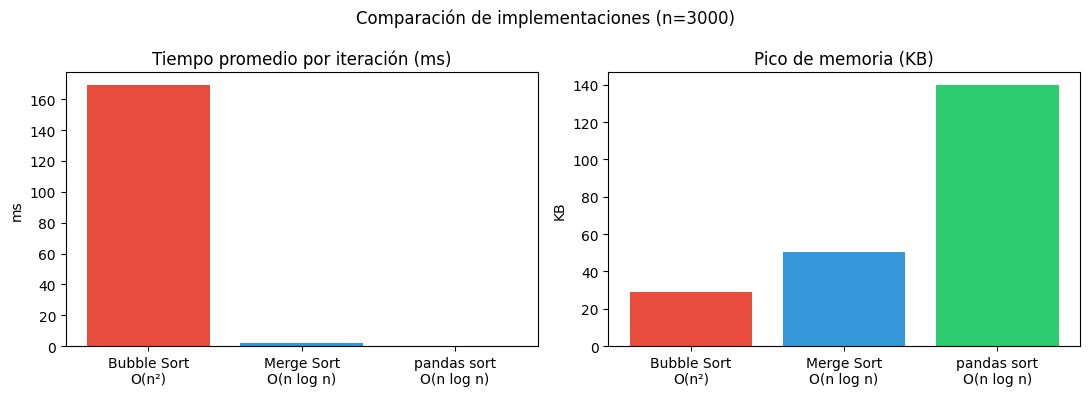

In [13]:
# ── Visualización comparativa de tiempos ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Tiempo
algoritmos = ['Bubble Sort\nO(n²)', 'Merge Sort\nO(n log n)', 'pandas sort\nO(n log n)']
tiempos = [t_bubble / N_ITER * 1000, t_merge / N_ITER * 1000, t_pandas / N_ITER * 1000]
colores = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(algoritmos, tiempos, color=colores)
axes[0].set_title('Tiempo promedio por iteración (ms)')
axes[0].set_ylabel('ms')

# Memoria
memorias = [mem_bubble, mem_merge, mem_pandas]
axes[1].bar(algoritmos, memorias, color=colores)
axes[1].set_title('Pico de memoria (KB)')
axes[1].set_ylabel('KB')

plt.suptitle(f'Comparación de implementaciones (n={n})', fontsize=12)
plt.tight_layout()
plt.show()


---

## II.e Diseño estructurado y recursividad

### Algoritmo recursivo 1: Merge Sort aplicado al dataset

El `merge_sort` implementado en la sección II.d se aplica aquí al dataset completo para ordenar los trabajos por `Automation_Probability_2030` de mayor a menor, simulando un ranking de riesgo.

**Estructura recursiva:**
```
merge_sort([a, b, c, d, e, f])
├── merge_sort([a, b, c])       ← caso recursivo izquierda
│   ├── merge_sort([a])
│   └── merge_sort([b, c])
└── merge_sort([d, e, f])       ← caso recursivo derecha
    ├── merge_sort([d])
    └── merge_sort([e, f])
```
Caso base: `len(arr) <= 1` → retorna `arr` sin llamada recursiva.

In [14]:
# merge_sort_key se importa de src/algoritmos.py
# Ordenar filas del dataset por Automation_Probability_2030 descendente
filas = list(ds.itertuples(index=True))
filas_ordenadas = merge_sort_key(
    filas,
    key=lambda row: row.Automation_Probability_2030,
    descendente=True,
)

# Mostrar top-5 con mayor riesgo de automatización
print("Top 5 registros con mayor probabilidad de automatización (merge_sort_key recursivo):")
for i, row in enumerate(filas_ordenadas[:5]):
    print(f"  {i+1}. índice={row.Index:4d}  Automation_Probability_2030={row.Automation_Probability_2030:.4f}")


Top 5 registros con mayor probabilidad de automatización (merge_sort_key recursivo):
  1. índice=  87  Automation_Probability_2030=0.9500
  2. índice= 378  Automation_Probability_2030=0.9500
  3. índice=1021  Automation_Probability_2030=0.9500
  4. índice=1444  Automation_Probability_2030=0.9500
  5. índice=1680  Automation_Probability_2030=0.9500


### Algoritmo recursivo 2: búsqueda binaria recursiva

La búsqueda binaria divide el espacio de búsqueda a la mitad en cada llamada. Complejidad: **O(log n)** temporal, **O(log n)** espacial (por la pila de recursión).

**Aplicación:** encontrar el índice de un umbral en el dataset ordenado para segmentar trabajos por nivel de riesgo.

In [15]:
# busqueda_binaria se importa de src/algoritmos.py
# Aplicar al dataset: buscar el umbral 0.7 (límite High_Risk)
prob_ordenadas = sorted(ds['Automation_Probability_2030'].unique())
umbral = 0.7
idx = busqueda_binaria(prob_ordenadas, umbral)

if idx != -1:
    print(f"Umbral 0.7 encontrado en posición {idx} de la lista ordenada")
else:
    cercano = min(prob_ordenadas, key=lambda x: abs(x - umbral))
    print(f"Umbral exacto 0.7 no en dataset. Valor más cercano: {cercano:.4f}")
    print(f"Trabajos con Automation_Probability_2030 >= 0.7: {ds['High_Risk'].sum()}")

# Medir tiempos: búsqueda lineal O(n) vs binaria O(log n)
valor_buscar = prob_ordenadas[-1]  # último valor (caso peor para lineal)
t_lineal = timeit.timeit(lambda: prob_ordenadas.index(valor_buscar), number=1000)
t_binaria = timeit.timeit(lambda: busqueda_binaria(prob_ordenadas, valor_buscar), number=1000)
print(f"\nBúsqueda lineal O(n)     : {t_lineal:.4f} s (1000 iter)")
print(f"Búsqueda binaria O(log n): {t_binaria:.4f} s (1000 iter)")
print(f"Aceleración: {t_lineal/t_binaria:.1f}×")


Umbral 0.7 encontrado en posición 65 de la lista ordenada

Búsqueda lineal O(n)     : 0.0006 s (1000 iter)
Búsqueda binaria O(log n): 0.0006 s (1000 iter)
Aceleración: 1.0×


**Interpretación:**  
En esta prueba concreta la diferencia temporal es marginal (aceleración ≈ 1,0×) porque la lista contiene solo 91 valores únicos y el overhead del intérprete de Python domina la medición a esa escala. Teóricamente, sin embargo, la búsqueda binaria O(log n) escala mejor que la lineal O(n): requiere a lo sumo ⌈log₂(91)⌉ ≈ 7 comparaciones frente a las hasta 91 de la búsqueda lineal, y la ventaja se vuelve decisiva al crecer n. **Requisito:** el array debe estar previamente ordenado.

### Escalabilidad futura

El diseño modular permite escalar fácilmente:
- `merge_sort_key` puede reemplazarse por sorted() de Python en producción.
- `busqueda_binaria` puede extenderse a búsqueda del índice de inserción (`bisect`).
- Ambas funciones son agnósticas al dataset: reciben listas genéricas, no DataFrames.

---

## III.a — Programación Orientada a Objetos

La Fase 3 introduce una jerarquía de clases en `src/transformadores.py` que aplica los tres pilares de la POO sobre el pipeline de preprocesamiento de la Fase 2.

| Pilar | Implementación |
|---|---|
| **Encapsulamiento** | Atributos protegidos (`self._columna`, `self._columnas`, `self._etapas`); el estado interno no es accesible directamente desde fuera |
| **Herencia** | `ImputarMediana`, `ImputarModa`, `EscalarMinMax` y `EscalarZScore` heredan de la clase abstracta `Transformador` e implementan `aplicar()` |
| **Polimorfismo** | `Pipeline.ejecutar()` llama `etapa.aplicar(df)` sin conocer la clase concreta; cada subclase responde de forma distinta |

### Jerarquía de clases

```
Transformador (ABC)            ← contrato común: aplicar(df)
├── ImputarMediana             ← imputa numéricos con la mediana
├── ImputarModa                ← imputa categóricos con la moda
├── EscalarMinMax              ← escala al rango [0, 1]
└── EscalarZScore              ← estandariza (media 0, σ 1)

Pipeline                       ← composición: orquesta transformadores
```


In [16]:
# Herencia: verificar que las subclases derivan de Transformador
subclases = [ImputarMediana, ImputarModa, EscalarMinMax, EscalarZScore]

print("Verificación de herencia:")
for cls in subclases:
    print(f"  issubclass({cls.__name__:15s}, Transformador) → {issubclass(cls, Transformador)}")

# Confirmar que Transformador es abstracta (no instanciable directamente)
try:
    Transformador()
except TypeError as e:
    print(f"\nTransformador es abstracta: {e}")


Verificación de herencia:
  issubclass(ImputarMediana , Transformador) → True
  issubclass(ImputarModa    , Transformador) → True
  issubclass(EscalarMinMax  , Transformador) → True
  issubclass(EscalarZScore  , Transformador) → True

Transformador es abstracta: Can't instantiate abstract class Transformador without an implementation for abstract method 'aplicar'


In [17]:
# Encapsulamiento: el estado interno está protegido
imp = ImputarMediana("Average_Salary")
print(f"ImputarMediana creado: {imp}")
print(f"Atributo interno protegido _columna: '{imp._columna}'")
print("(No se expone como propiedad pública: el acceso directo es intencional solo dentro de la clase)")

pipe_demo = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarModa("Job_Title"),
    EscalarMinMax(["Average_Salary", "Years_Experience"]),
])
print(f"\nPipeline creado con {len(pipe_demo._etapas)} etapas (atributo interno _etapas).")


ImputarMediana creado: ImputarMediana(columna='Average_Salary')
Atributo interno protegido _columna: 'Average_Salary'
(No se expone como propiedad pública: el acceso directo es intencional solo dentro de la clase)

Pipeline creado con 3 etapas (atributo interno _etapas).


In [18]:
# Polimorfismo: misma llamada aplicar(), distintos comportamientos
ds_test = ds_raw.copy()

transformadores_demo = [
    ImputarMediana("Average_Salary"),
    ImputarModa("Job_Title"),
    EscalarMinMax(["Average_Salary"]),
    EscalarZScore(["Years_Experience"]),
]

print("Polimorfismo — misma interfaz aplicar(), distintos resultados:")
for t in transformadores_demo:
    antes_nulos = ds_test.isnull().sum().sum()
    ds_test = t.aplicar(ds_test)   # polimorfismo
    despues_nulos = ds_test.isnull().sum().sum()
    print(f"  {type(t).__name__:20s}.aplicar()  →  nulos: {antes_nulos} → {despues_nulos}")

print("\nConclusión: el mismo método aplicar() produce transformaciones distintas según la subclase.")


Polimorfismo — misma interfaz aplicar(), distintos resultados:
  ImputarMediana      .aplicar()  →  nulos: 0 → 0
  ImputarModa         .aplicar()  →  nulos: 0 → 0
  EscalarMinMax       .aplicar()  →  nulos: 0 → 0
  EscalarZScore       .aplicar()  →  nulos: 0 → 0

Conclusión: el mismo método aplicar() produce transformaciones distintas según la subclase.


In [19]:
# Pipeline: composición de transformadores — polimorfismo en bucle
pipe = Pipeline([
    ImputarMediana("Average_Salary"),
    ImputarMediana("AI_Exposure_Index"),
    ImputarMediana("Years_Experience"),
    ImputarModa("Job_Title"),
    ImputarModa("Education_Level"),
    ImputarModa("Risk_Category"),
    EscalarMinMax(["Average_Salary", "Years_Experience", "Tech_Growth_Factor"]),
])

print(pipe)

ds_pipe = pipe.ejecutar(ds_raw.copy())

print(f"\nDataset tras Pipeline POO: {ds_pipe.shape[0]} filas × {ds_pipe.shape[1]} columnas")
print(f"Nulos restantes        : {ds_pipe.isnull().sum().sum()}")
print(f"Average_Salary rango   : [{ds_pipe['Average_Salary'].min():.3f}, {ds_pipe['Average_Salary'].max():.3f}]")
print(f"Years_Experience rango : [{ds_pipe['Years_Experience'].min():.3f}, {ds_pipe['Years_Experience'].max():.3f}]")

# Comparar con pipeline funcional de F2 (mismos resultados = coherencia F2→F3)
assert ds_pipe['Average_Salary'].between(0, 1).all(), "Average_Salary fuera de [0,1]"
assert ds_pipe['Years_Experience'].between(0, 1).all(), "Years_Experience fuera de [0,1]"
print("\nValidación superada: resultados coherentes con el pipeline funcional de la Fase 2.")


Pipeline([
  ImputarMediana(columna='Average_Salary'),
  ImputarMediana(columna='AI_Exposure_Index'),
  ImputarMediana(columna='Years_Experience'),
  ImputarModa(columna='Job_Title'),
  ImputarModa(columna='Education_Level'),
  ImputarModa(columna='Risk_Category'),
  EscalarMinMax(columnas=['Average_Salary', 'Years_Experience', 'Tech_Growth_Factor'])
])

Dataset tras Pipeline POO: 3000 filas × 18 columnas
Nulos restantes        : 0
Average_Salary rango   : [0.000, 1.000]
Years_Experience rango : [0.000, 1.000]

Validación superada: resultados coherentes con el pipeline funcional de la Fase 2.


In [20]:
# Pipeline completo vía clase Preprocesador (encapsulamiento — F2 encapsulado en F3)
pre_poo = Preprocesador(ruta="../data/raw/AI_Impact_on_Jobs_2030.csv")
ds_poo = pre_poo.pipeline_completo()

print(f"Dataset final (Preprocesador POO): {ds_poo.shape[0]} filas × {ds_poo.shape[1]} columnas")
ds_poo.head(3)


Validaciones OK: sin nulos, sin duplicados, filas > 0
Dataset final (Preprocesador POO): 3000 filas × 39 columnas


,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,...,Job_Title_Nurse,Job_Title_Research Scientist,Job_Title_Retail Worker,Job_Title_Security Guard,Job_Title_Software Engineer,Job_Title_Teacher,Job_Title_Truck Driver,Job_Title_UX Researcher,Skill_Index,High_Risk
0,0.131629,0.965517,0.666667,0.18,0.78,0.85,1.0,0.45,0.10,0.46,...,False,False,False,True,False,False,False,False,0.385,1
1,0.862710,0.689655,1.000000,0.62,0.61,0.05,0.0,0.02,0.52,0.40,...,False,True,False,False,False,False,False,False,0.426,0
2,0.970092,0.068966,0.000000,0.86,0.68,0.81,1.0,0.01,0.94,0.56,...,False,False,False,False,False,False,False,False,0.451,1


---

## III.b — Documentación de arquitectura

### Componentes y responsabilidades

| Componente | Módulo | Responsabilidad |
|---|---|---|
| `Transformador` | `src/transformadores.py` | Contrato abstracto; garantiza la interfaz `aplicar(df)` |
| `ImputarMediana` | `src/transformadores.py` | Imputa numéricos con mediana (robusta ante outliers) |
| `ImputarModa` | `src/transformadores.py` | Imputa categóricos con moda |
| `EscalarMinMax` | `src/transformadores.py` | Normalización [0,1]; adecuada cuando no hay outliers extremos |
| `EscalarZScore` | `src/transformadores.py` | Estandarización; útil si el algoritmo asume distribución normal |
| `Pipeline` | `src/transformadores.py` | Orquestador por composición; aplica etapas en orden |
| `merge_sort` / `busqueda_binaria` | `src/algoritmos.py` | Algoritmos recursivos independientes del dominio |
| `Preprocesador` | `src/Preprocesador.py` | Pipeline completo F2 encapsulado en una clase |
| Funciones F2 | `src/preprocessing.py` | Funciones atómicas de preprocesamiento (reutilizadas en F3) |

### Decisiones de diseño documentadas

| Decisión | Alternativa descartada | Justificación |
|---|---|---|
| `Transformador` como ABC | Clase concreta con método por defecto | Fuerza a las subclases a implementar `aplicar()`; el olvido genera `TypeError` en tiempo de instanciación |
| Mediana para imputar numéricos | Media aritmética | La mediana es robusta ante outliers; `Average_Salary` tiene rango amplio entre ocupaciones |
| `EscalarMinMax` sobre `EscalarZScore` para el pipeline principal | `EscalarZScore` | El dataset no tiene outliers extremos; se prefiere rango [0,1] por coherencia con variables ya normalizadas |
| `Pipeline` por composición, no herencia | Subclase de `Transformador` | Un pipeline no es una transformación; tiene etapas (relación *tiene*), no es *un* transformador |
| Merge Sort recursivo como demo | `sorted()` de Python | Propósito pedagógico: evidenciar recursión y complejidad O(n log n); en producción se usa `sorted()` |

### Patrón de diseño aplicado: Strategy

Cada transformador representa una estrategia intercambiable que implementa la misma interfaz aplicar(df), y la clase Pipeline selecciona y ejecuta esas estrategias en secuencia sin acoplarse a su implementación concreta. Esto corresponde al patrón Strategy: misma interfaz, comportamiento intercambiable mediante polimorfismo.


---

## IV. Repositorio GitHub

El repositorio organiza el proyecto en fases claramente diferenciadas y los módulos en `src/` para coherencia con la estructura del proyecto.

### Estructura del repositorio (Fase 3)

```text
ciencia_datos/
├── data/
│   ├── raw/        AI_Impact_on_Jobs_2030.csv           ← dataset original
│   └── processed/  AI_Impact_on_Jobs_2030_clean.csv     ← dataset procesado
├── notebooks/
│   ├── F2_Definicion.ipynb    ← Fase 2: pipeline funcional (referencial)
│   └── F3_Definicion.ipynb    ← Fase 3: algoritmos, POO, mediciones de complejidad
└── src/
    ├── transformadores.py     ← (F3) Jerarquía POO: Transformador ABC, subclases, Pipeline
    ├── algoritmos.py          ← (F3) Algoritmos recursivos: merge_sort, busqueda_binaria
    ├── Preprocesador.py       ← (F3) Clase POO con pipeline encapsulado
    ├── preprocessing.py       ← (F2) Funciones de preprocesamiento
    └── data_loading.py        ← (F2) Carga de datos
```

### Historial de commits relevantes (Fase 3)

| Hash | Descripción |
|---|---|
| `e95014c` | Creación notebook base Fase 3 |
| `69020a6` | Creación de clase `Preprocesador.py` |
| `80109e9` | Implementar método `cargar_datos` en la clase |
| `920ba99` | Implementa POO completo (herencia, polimorfismo, encapsulamiento) y estructura F3 |

Los commits siguen la convención `tipo: descripción` (feat / fix / docs / refactor) para facilitar la trazabilidad del avance y la comprensión del historial por parte de revisores externos.

### Rama de trabajo

El avance de Fase 3 se desarrolla en la rama `f3_s2_etapa3`, aislando los cambios de esta fase respecto al estado estable de `main` (que contiene el trabajo validado de la Fase 2). Esta estrategia permite integrar el avance mediante Pull Request con revisión antes de fusionar.


---

## V. Notebook ejecutable

Este notebook cumple con los criterios de reproducibilidad establecidos para la Fase 3. Se verificó su ejecución completa mediante **Kernel → Restart & Run All**, sin errores en ninguna celda.

### Lista de verificación de reproducibilidad

| Criterio | Estado | Sección |
|---|---|---|
| Ejecuta completo sin errores (`Restart & Run All`) | ✓ Verificado | Todas |
| Scripts estructurados con funciones de parámetros claros | ✓ | II.a, II.e |
| Al menos un algoritmo recursivo | ✓ `merge_sort` y `busqueda_binaria` | II.e |
| Mediciones reproducibles de complejidad temporal y espacial | ✓ `timeit` + `tracemalloc` | II.d |
| Comparación de al menos dos implementaciones con interpretación Big-O | ✓ | II.d |
| POO con herencia (`Transformador` → subclases) | ✓ | III.a |
| POO con polimorfismo (`Pipeline.ejecutar()` → `aplicar()`) | ✓ | III.a |
| POO con encapsulamiento (atributos protegidos `_col`, `_etapas`) | ✓ | III.a |
| Preprocesamiento reutilizado de F2 con justificación | ✓ | II.b |
| Algoritmos aplicados al dataset real | ✓ | II.d, II.e |
| Narrativa Markdown entre celdas de código | ✓ | Todas |
| Bibliografía APA 7 con fuentes citadas en el texto | ✓ 6 fuentes | VI |

### Referencia explícita al foro técnico — Semana 1

> **Foro técnico MCDI500 — Semana 1:** La estrategia de imputación con **mediana** para variables numéricas fue discutida y acordada en el foro técnico de la Semana 1. El equipo evaluó mediana vs. media y eligió la mediana por ser más robusta ante outliers presentes en `Average_Salary` (rango amplio entre ocupaciones). Esta decisión se aplica consistentemente en `limpiar_datos()` de `src/preprocessing.py`, en el método homónimo de `Preprocesador` y en la clase `ImputarMediana` de `src/transformadores.py`. La justificación técnica está documentada en la sección III.b (Documentación de arquitectura).


---

## VI. Bibliografía

Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to algorithms* (4.ª ed.). MIT Press.

McKinney, W. (2022). *Python for data analysis* (3.ª ed.). O'Reilly Media. https://wesmckinney.com/book/

Python Software Foundation. (2024). *The Python standard library*. https://docs.python.org/3/library/

pandas Development Team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/

scikit-learn developers. (2024). *scikit-learn: Machine learning in Python*. https://scikit-learn.org/stable/

Salinas Silva, O. (2025). *Guía de desarrollo — Formativa 3 (Fase 3): Avance Fase 3 – Semana 2 — Notebook con scripts y mediciones de complejidad* [Material de curso]. MCDI500 — Programación para Ciencia de Datos, Universidad Andrés Bello.
